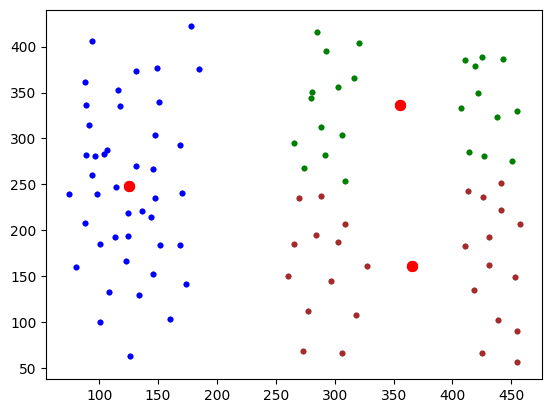

In [1]:
# Алгоритм Ллойда (метод K-средних для кластеризации)
import time

import numpy as np
import matplotlib.pyplot as plt

# x = [(98, 62), (80, 95), (71, 130), (89, 164), (137, 115), (107, 155), (109, 105), (174, 62), (183, 115), (164, 153),
#      (142, 174), (140, 80), (308, 123), (229, 171), (195, 237), (180, 298), (179, 340), (251, 262), (300, 176),
#      (346, 178), (311, 237), (291, 283), (254, 340), (215, 308), (239, 223), (281, 207), (283, 156)]

# x = [(64, 150), (84, 112), (106, 90), (154, 64), (192, 62), (220, 82), (244, 92), (271, 111), (275, 137), (286, 161), (56, 178), (80, 156), (101, 131), (123, 104), (155, 94), (191, 100), (242, 70), (231, 114), (272, 95), (261, 131), (299, 136), (308, 124), (128, 78), (47, 128), (47, 159), (137, 186), (166, 228), (171, 250), (194, 272), (221, 287), (253, 292), (308, 293), (332, 280), (385, 256), (398, 237), (413, 205), (435, 166), (447, 137), (422, 126), (400, 154), (389, 183), (374, 214), (358, 235), (321, 250), (274, 263), (249, 263), (208, 230), (192, 204), (182, 174), (147, 205), (136, 246), (147, 255), (182, 282), (204, 298), (252, 316), (312, 321), (349, 313), (393, 288), (417, 259), (434, 222), (443, 187), (463, 174)]
x = [(126, 63), (101, 100), (80, 160), (88, 208), (89, 282), (88, 362), (94, 406), (149, 377), (147, 304), (147, 235), (146, 152), (160, 103), (174, 142), (169, 184), (170, 241), (169, 293), (185, 376), (178, 422), (116, 353), (124, 194), (273, 69), (277, 112), (260, 150), (265, 185), (270, 235), (265, 295), (281, 351), (285, 416), (321, 404), (316, 366), (306, 304), (309, 254), (309, 207), (327, 161), (318, 108), (306, 66), (425, 66), (418, 135), (411, 183), (413, 243), (414, 285), (407, 333), (411, 385), (443, 387), (455, 330), (441, 252), (457, 207), (453, 149), (455, 90), (455, 56), (439, 102), (431, 162), (431, 193), (426, 236), (427, 281), (438, 323), (419, 379), (425, 389), (422, 349), (451, 275), (441, 222), (297, 145), (284, 195), (288, 237), (292, 282), (288, 313), (303, 356), (293, 395), (274, 268), (280, 344), (303, 187), (114, 247), (131, 270), (144, 215), (124, 219), (98, 240), (96, 281), (146, 267), (136, 221), (123, 166), (101, 185), (152, 184), (104, 283), (74, 239), (107, 287), (118, 335), (89, 336), (91, 315), (151, 340), (131, 373), (108, 133), (134, 130), (94, 260), (113, 193)]


M = np.mean(x, axis=0)      # вычисление средних по каждой координате
D = np.var(x, axis=0)       # вычисление дисперсий по каждой координате
K = 3                       # число кластеров
ma = [np.random.normal(M, np.sqrt(D / 10), 2) for n in range(K)]        # начальные центры кластеров
# ma = [np.array(x[0]), np.array(x[1])]
ro = lambda x_vect, m_vect: np.mean((x_vect - m_vect) ** 2)             # евклидова метрика

COLORS = ('green', 'blue', 'brown', 'black')     # цветов должно быть не меньше кластеров (>= K)

plt.ion()
n = 0
while n < 10:
    X = [[] for i in range(K)]                  # инициализация пустого двумерного списка для хранения объектов кластеров

    for x_vect in x:
        r = [ro(x_vect, m) for m in ma]         # вычисление расстояний для текущего образа до центров кластеров
        X[np.argmin(r)].append(x_vect)          # добавление образа к кластеру с ближайшим центром

    ma = [np.mean(xx, axis=0) for xx in X]      # пересчет центров кластеров

    plt.clf()
    # отображение найденных кластеров
    for i in range(K):
        xx = np.array(X[i]).T
        plt.scatter(xx[0], xx[1], s=10, color=COLORS[i])

    # отображение центров кластеров
    mx = [m[0] for m in ma]
    my = [m[1] for m in ma]
    plt.scatter(mx, my, s=50, color='red')

    plt.draw()
    plt.gcf().canvas.flush_events()
#    plt.savefig(f"lloyd {n+1}.png")
    time.sleep(0.2)

    n += 1

plt.ioff()

# отображение найденных кластеров
for i in range(K):
    xx = np.array(X[i]).T
    plt.scatter(xx[0], xx[1], s=10, color=COLORS[i])

# отображение центров кластеров
mx = [m[0] for m in ma]
my = [m[1] for m in ma]
plt.scatter(mx, my, s=50, color='red')

plt.show()

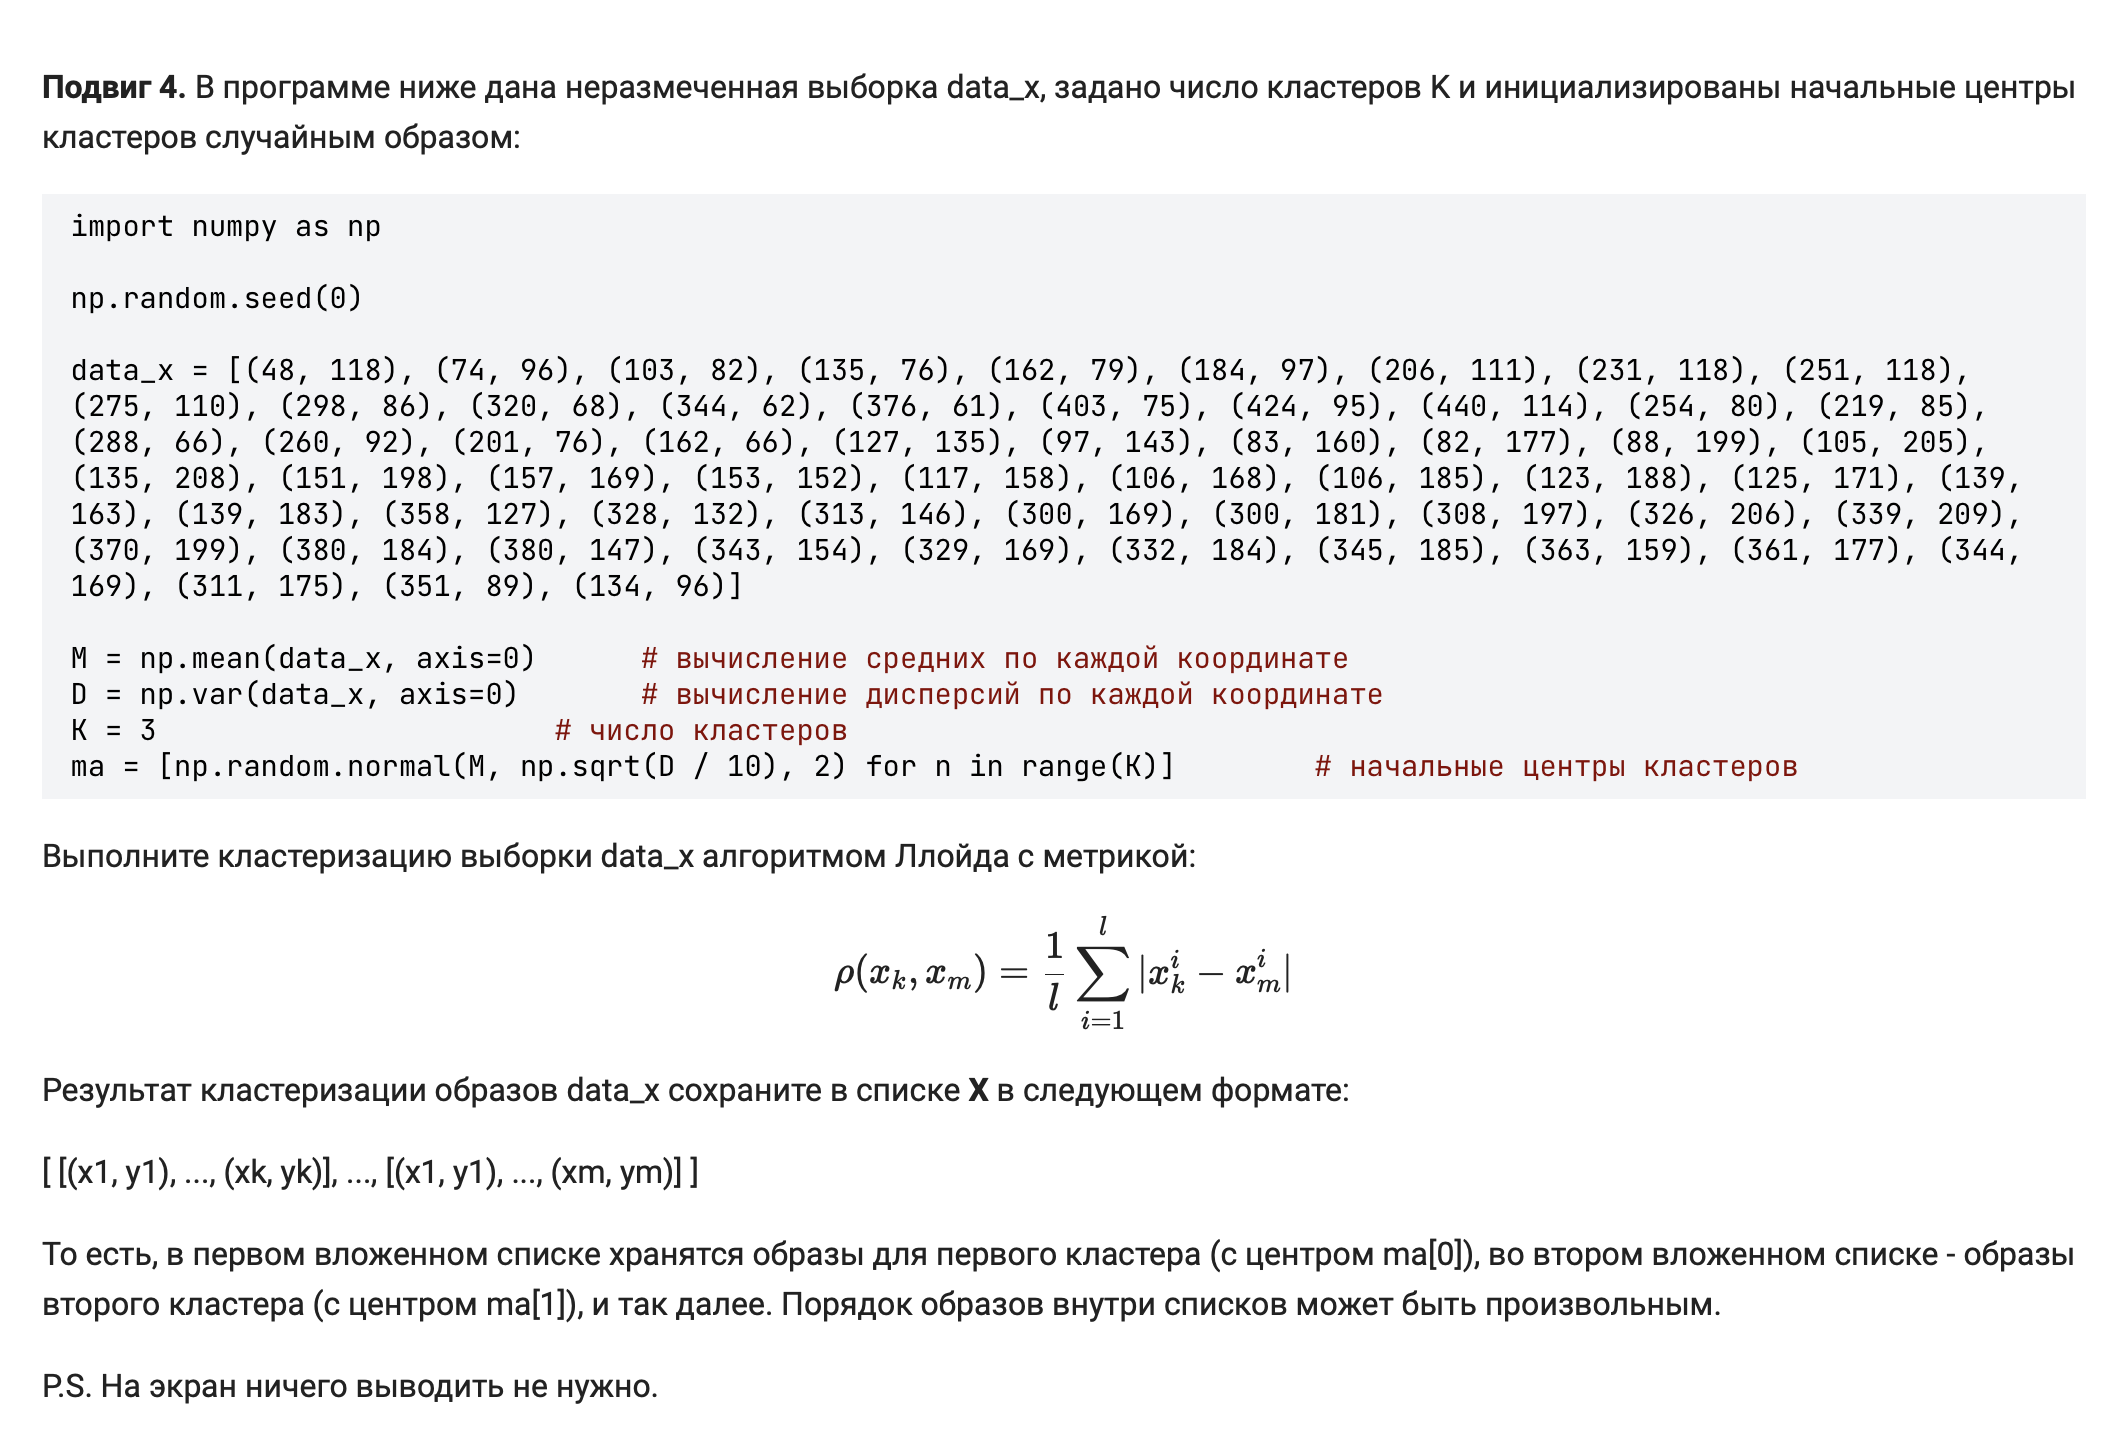

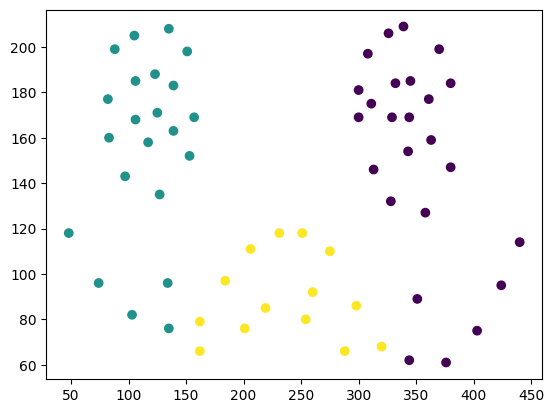

In [32]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

data_x = [(48, 118), (74, 96), (103, 82), (135, 76), (162, 79), (184, 97), (206, 111), (231, 118), (251, 118), (275, 110), (298, 86), (320, 68), (344, 62), (376, 61), (403, 75), (424, 95), (440, 114), (254, 80), (219, 85), (288, 66), (260, 92), (201, 76), (162, 66), (127, 135), (97, 143), (83, 160), (82, 177), (88, 199), (105, 205), (135, 208), (151, 198), (157, 169), (153, 152), (117, 158), (106, 168), (106, 185), (123, 188), (125, 171), (139, 163), (139, 183), (358, 127), (328, 132), (313, 146), (300, 169), (300, 181), (308, 197), (326, 206), (339, 209), (370, 199), (380, 184), (380, 147), (343, 154), (329, 169), (332, 184), (345, 185), (363, 159), (361, 177), (344, 169), (311, 175), (351, 89), (134, 96)]
data_x = np.array(data_x)

M = np.mean(data_x, axis=0)      # вычисление средних по каждой координате
D = np.var(data_x, axis=0)       # вычисление дисперсий по каждой координате
K = 3                       # число кластеров
ma = np.array([np.random.normal(M, np.sqrt(D / 10), 2) for n in range(K)])     # начальные центры кластеров

for i in range(100):
    diff = data_x[:, np.newaxis, :] - ma[np.newaxis, :, :]
    dist = 1 / len(data_x) * np.abs(diff).sum(axis=2)
    y = np.argmin(dist, axis=1)
    ma = np.array([data_x[y == i].mean(axis=0) for i in range(K)])

X = [data_x[y == i] for i in range(K)]

plt.scatter(data_x[:, 0], data_x[:, 1], c=y)
plt.show()

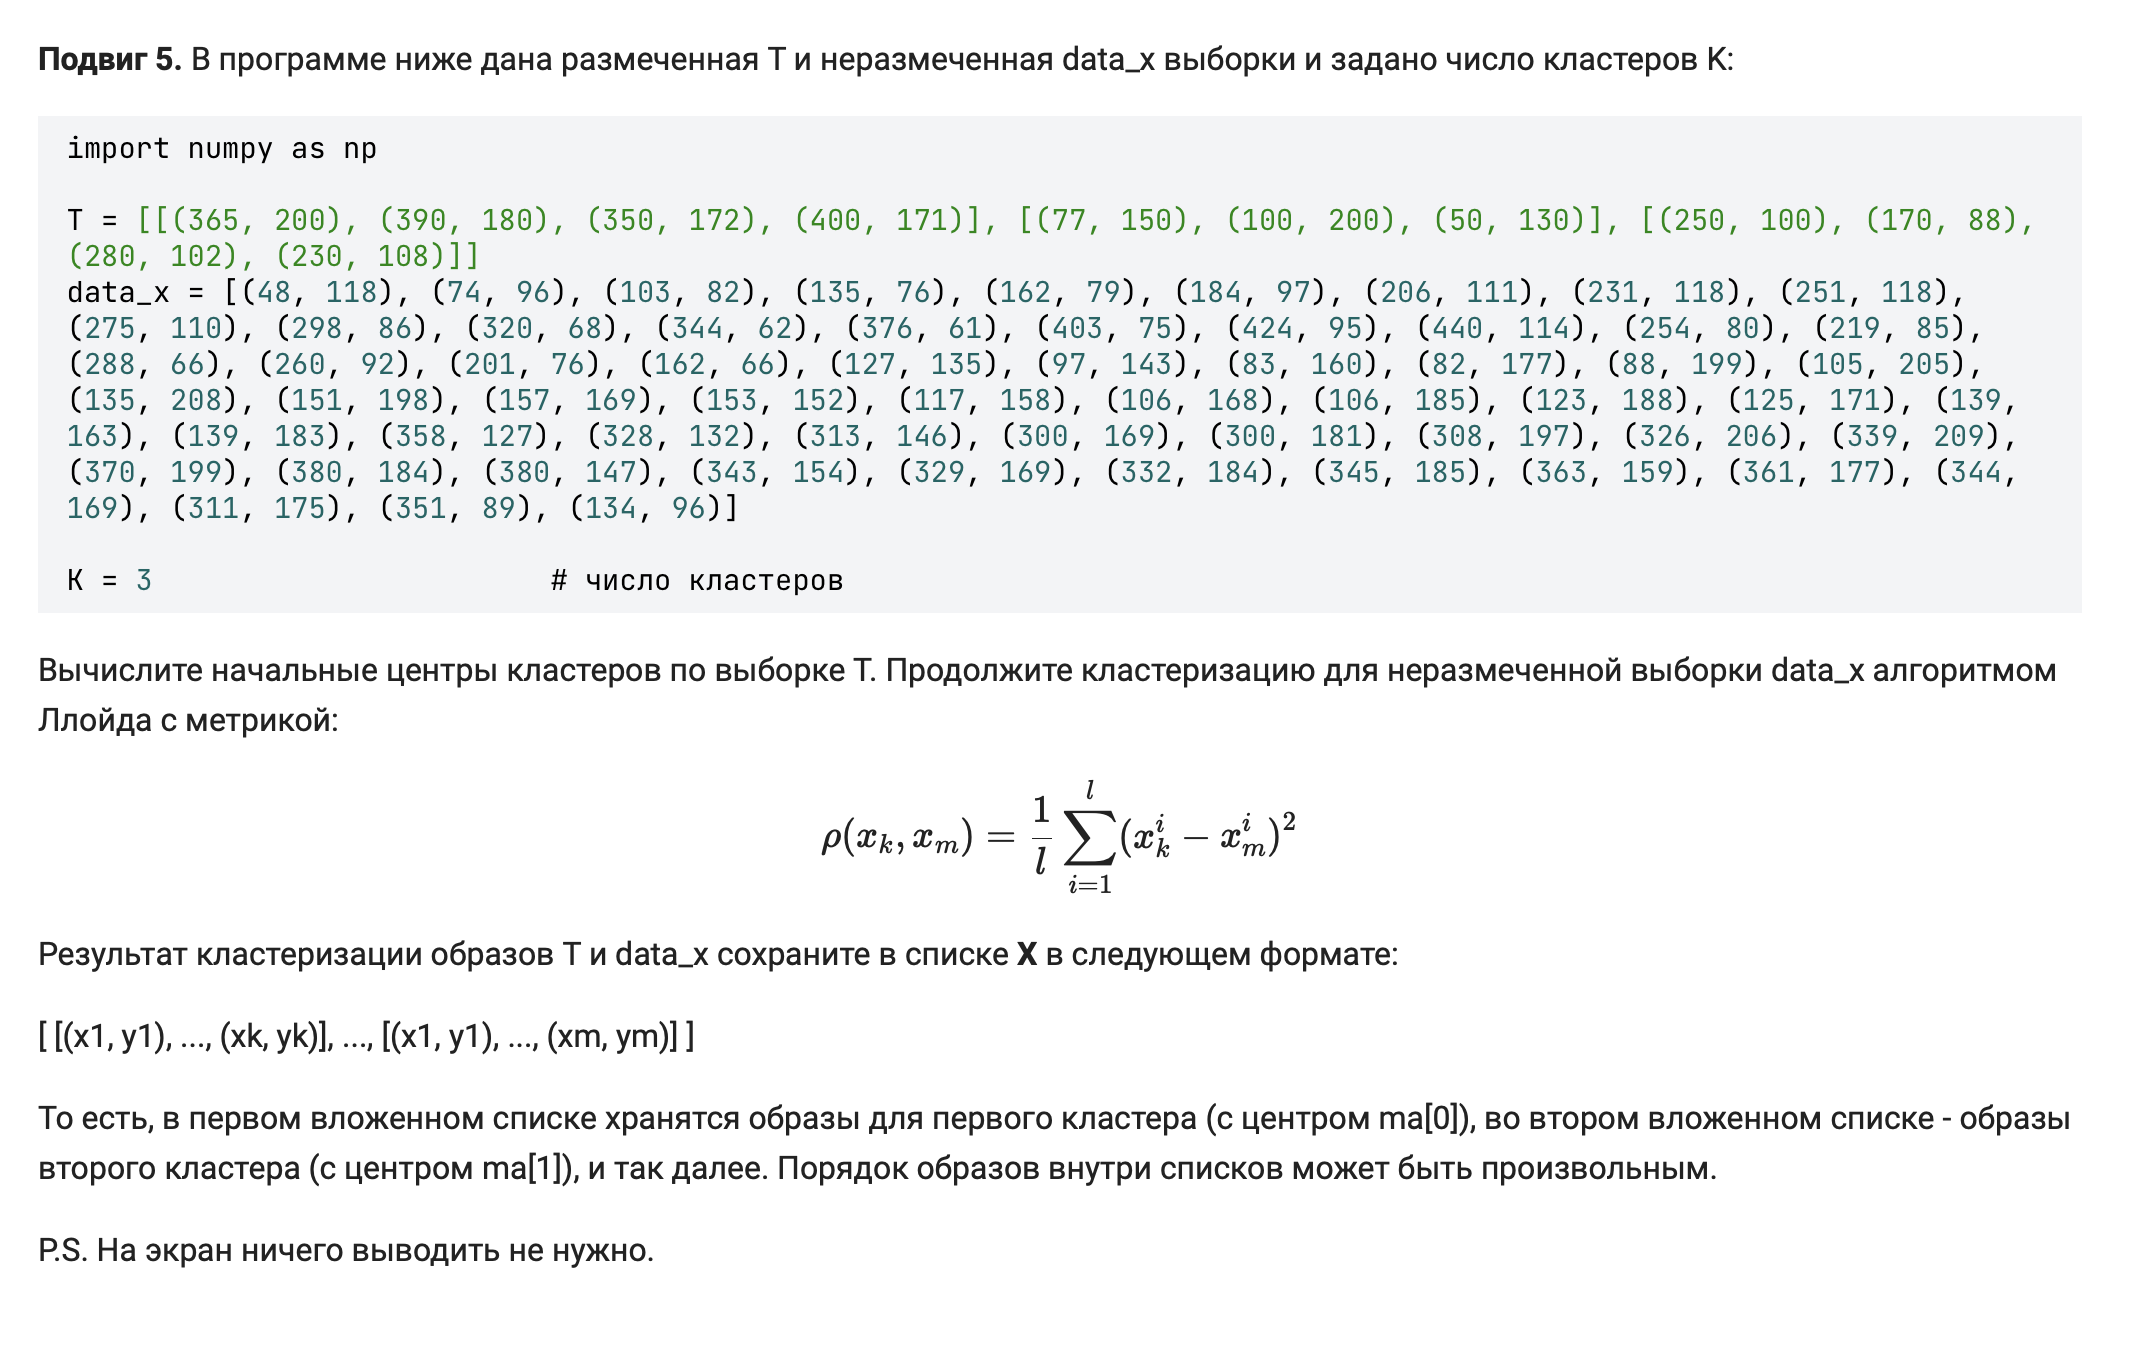

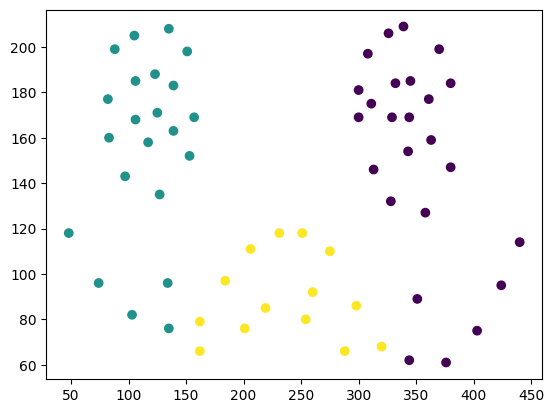

In [ ]:
import numpy as np
import matplotlib.pylab as plt

T = [[(365, 200), (390, 180), (350, 172), (400, 171)], [(77, 150), (100, 200), (50, 130)], [(250, 100), (170, 88), (280, 102), (230, 108)]]
data_x = [(48, 118), (74, 96), (103, 82), (135, 76), (162, 79), (184, 97), (206, 111), (231, 118), (251, 118), (275, 110), (298, 86), (320, 68), (344, 62), (376, 61), (403, 75), (424, 95), (440, 114), (254, 80), (219, 85), (288, 66), (260, 92), (201, 76), (162, 66), (127, 135), (97, 143), (83, 160), (82, 177), (88, 199), (105, 205), (135, 208), (151, 198), (157, 169), (153, 152), (117, 158), (106, 168), (106, 185), (123, 188), (125, 171), (139, 163), (139, 183), (358, 127), (328, 132), (313, 146), (300, 169), (300, 181), (308, 197), (326, 206), (339, 209), (370, 199), (380, 184), (380, 147), (343, 154), (329, 169), (332, 184), (345, 185), (363, 159), (361, 177), (344, 169), (311, 175), (351, 89), (134, 96)]
x = data_x + T[0] + T[1] + T[2]
data_x = np.array(data_x)
x = np.array(x)

K = 3                       # число кластеров

# здесь продолжайте программу
ma = np.array([np.mean(T[i], axis=0) for i in range(K)])

for i in range(100):
    diff = data_x[:, np.newaxis, :] - ma[np.newaxis, :, :]
    dist = np.sum(diff ** 2, axis=2)
    y = np.argmin(dist, axis=1)

    for i in range(K):
        T[i] += data_x[y == i].tolist()

    ma = np.array([np.mean(T[i], axis=0) for i in range(K)])

X = T

plt.scatter(data_x[:, 0], data_x[:, 1], c=y)
plt.show()